# Noisy GPG cooperativity sweep

This notebook fixes the physical amplitude-damping probability to
\(p=10^{-3}\), optimizes the GPG pulse sequences using the finite-cooperativity erroneous-GPG model, and plots the final recovered infidelity versus cooperativity.

The noisy-GPG knob in this notebook is the `COOPERATIVITIES` array; larger values approach the noiseless GPG limit.  The current implementation uses the noisy density-matrix GPG model during pulse optimization and then evaluates the recovered state using the existing staged recovery assembly.

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "python" / "codes").exists())
sys.path.insert(0, str(repo_root / "python"))

from codes import gpgs
from codes.bk_recovery import petz_recovery_kraus
from codes.codewords import bgmcode_kets_in_top_block
from codes.noisemodel import noisemodel


## Physical setup

We use the maximally mixed logical state
\[
\rho_C=\frac{1}{2}\left(|0_L\rangle\langle 0_L|+|1_L\rangle\langle 1_L|\right)
\]
for the \((3,3,1)\) BGM code.  The state passes through the exact global symmetric AD channel at fixed \(p=10^{-3}\).  The recovery Kraus operators are built from the approximate global-AD map, as in the noiseless GPG notebook.

In [11]:
b, g, m = 3, 3, 1
N = 2 * b * m + g
system_dim = N + 1
reference_weight = N

P_AD = 1e-3
COOPERATIVITIES = np.array([1e6, 1e7, 1e8, 1e9, 1e10], dtype=float)
GPG_MODE = "erroneous"

ket0, ket1, _ = bgmcode_kets_in_top_block(b, g, m, return_qutip=True)
rho_c = (ket0 * ket0.dag() + ket1 * ket1.dag()) / 2


def exact_global_ad(p):
    return noisemodel(
        "global symmetric amplitude damping",
        N,
        float(p),
        1.0,
        return_rep="super",
        dynamics="exact",
    )


def approximate_petz_recovery(p):
    approx_kraus = noisemodel(
        "global symmetric amplitude damping",
        N,
        float(p),
        1.0,
        return_rep="kraus",
        dynamics="approx",
    )
    approx_kraus = gpgs.restrict_operators_to_dimension(approx_kraus, system_dim)
    return petz_recovery_kraus(approx_kraus, rho_c)


setup_summary = pd.DataFrame([
    {
        "code": "BGM (3,3,1)",
        "N": N,
        "system dimension": system_dim,
        "input state": "rho_C",
        "AD probability p": P_AD,
        "GPG mode": GPG_MODE,
        "cooperativities": ", ".join(f"{c:.0e}" for c in COOPERATIVITIES),
        "GPG reference": f"|D_{reference_weight}^{N}>",
        "recovery Kraus operators": len(approximate_petz_recovery(P_AD)),
    }
])
setup_summary


,code,N,system dimension,input state,AD probability p,GPG mode,cooperativities,GPG reference,recovery Kraus operators
0,"BGM (3,3,1)",9,10,rho_C,0.001,erroneous,"1e+06, 1e+07, 1e+08, 1e+09, 1e+10",|D_9^9>,4


## Run the cooperativity sweep

This can take a while because each cooperativity value re-optimizes the nontrivial GPG state-preparation targets.  The cell stores results in a cache file, so rerunning the notebook can reuse completed points.  The sweep is run from largest to smallest cooperativity, with the noiseless cache used as an optional warm start when available.

In [12]:
RUN_OPTIMIZATION = False  # False means: use cache when available, otherwise compute missing points.
USE_NOISELESS_WARM_START = True

# Targeted refinement: these points are forced to recompute even if they are already cached.
# Set this to set() after the refined points look stable.
FORCE_RECOMPUTE_COOPERATIVITIES = {1e7, 1e8, 1e9}
REFINE_RESTART_FACTOR = 3
REFINE_MAXITER_FACTOR = 2
REFINE_EXTRA_PULSES = 0
KEEP_BEST_RECOMPUTE = True

cache_dir = repo_root / "datas" / "noiseless_gpgs_pulses" / "cache"
cache_dir.mkdir(parents=True, exist_ok=True)
NOISY_CACHE_PATH = cache_dir / "noisy_gpg_cooperativity_sweep_p1e-3.pkl"
NOISELESS_CACHE_PATH = cache_dir / "gpg_exact_ad_sweep_cache.pkl"


def load_cache(path):
    if path.exists():
        return gpgs.load_gpg_sweep_cache(path)
    return {"points": {}}


def should_force_recompute(C):
    return any(np.isclose(float(C), float(target)) for target in FORCE_RECOMPUTE_COOPERATIVITIES)


def settings_for_cooperativity(C):
    def settings_fn(label, eig_index, counter):
        settings = dict(gpgs.default_gpg_recovery_settings(label, eig_index, counter))
        if should_force_recompute(C):
            settings["restarts"] = max(settings["restarts"], int(np.ceil(settings["restarts"] * REFINE_RESTART_FACTOR)))
            settings["maxiter"] = max(settings["maxiter"], int(np.ceil(settings["maxiter"] * REFINE_MAXITER_FACTOR)))
            settings["pulses"] = int(settings["pulses"] + REFINE_EXTRA_PULSES)
        return settings

    return settings_fn


def noiseless_warm_start_sequences():
    if not USE_NOISELESS_WARM_START or not NOISELESS_CACHE_PATH.exists():
        return None
    cache = gpgs.load_gpg_sweep_cache(NOISELESS_CACHE_PATH)
    key = gpgs.gpg_recovery_cache_key(P_AD, gpg_mode="noiseless")
    point = cache.get("points", {}).get(key)
    if point is None:
        return None
    return point["pulse_sequences"]


noisy_cache = load_cache(NOISY_CACHE_PATH)
prior_sequences = noiseless_warm_start_sequences()
print("Using noiseless warm start:", prior_sequences is not None)
print("Forced recompute points:", sorted(f"{c:.0e}" for c in FORCE_RECOMPUTE_COOPERATIVITIES))


Using noiseless warm start: True
Forced recompute points: ['1e+07', '1e+08', '1e+09']


In [13]:
rows = []

for C in sorted(COOPERATIVITIES, reverse=True):
    cache_key = gpgs.gpg_recovery_cache_key(P_AD, gpg_mode=GPG_MODE, cooperativity=C)
    cached_point = noisy_cache["points"].get(cache_key)
    force_recompute = should_force_recompute(C)

    if cached_point is not None and not RUN_OPTIMIZATION and not force_recompute:
        print(f"Using cached C={C:.0e}")
        point = cached_point
    else:
        action = "Refining" if cached_point is not None and force_recompute else "Running"
        print(f"{action} C={C:.0e}")
        warm_start = cached_point["pulse_sequences"] if cached_point is not None and force_recompute else prior_sequences
        point_candidate = gpgs.run_gpg_recovery(
            rho_c,
            exact_global_ad,
            approximate_petz_recovery,
            P_AD,
            logical_kets=(ket0, ket1),
            reference_weight=reference_weight,
            prior_sequences=warm_start,
            settings_fn=settings_for_cooperativity(C),
            gpg_mode=GPG_MODE,
            cooperativity=C,
            log=print,
        )

        if cached_point is not None and KEEP_BEST_RECOMPUTE:
            old_inf = cached_point["metrics"]["GPG infidelity"]
            new_inf = point_candidate["metrics"]["GPG infidelity"]
            if new_inf > old_inf:
                print(f"  keeping previous cached point: old={old_inf:.6e}, new={new_inf:.6e}")
                point = cached_point
            else:
                print(f"  accepting refined point: old={old_inf:.6e}, new={new_inf:.6e}")
                point = point_candidate
        else:
            point = point_candidate

        noisy_cache["points"][cache_key] = point
        gpgs.save_gpg_sweep_cache(noisy_cache, NOISY_CACHE_PATH)

    prior_sequences = point["pulse_sequences"]
    rows.append({"cooperativity": C, **point["metrics"]})

results = pd.DataFrame(rows).sort_values("cooperativity").reset_index(drop=True)
results["monotonic violation"] = results["GPG infidelity"].diff().gt(0)

if results["monotonic violation"].any():
    bad = results.loc[results["monotonic violation"], ["cooperativity", "GPG infidelity"]]
    print("Nonmonotonic points remain after sorting by increasing C:")
    display(bad)
else:
    print("GPG infidelity is monotone nonincreasing with cooperativity on this grid.")

display_columns = [
    "cooperativity",
    "p",
    "exact infidelity",
    "GPG infidelity",
    "GPG - exact infidelity penalty",
    "max state-prep infidelity",
    "Tr GPG output",
    "total optimized seconds",
    "monotonic violation",
]
display(results[display_columns])


Using cached C=1e+10
Refining C=1e+09
  optimizing stage 0 split entangler eig=8 pulses=9 restarts=15 with warm start
    done 1-F_state=2.315e-03 elapsed=157.1s
  optimizing stage 0 split entangler eig=9 pulses=9 restarts=15 with warm start
    done 1-F_state=2.721e-03 elapsed=175.3s
  reused stage 1 split entangler eig=1 from optimized stage 0 split entangler:8 warm-start
  optimizing stage 1 split entangler eig=2 pulses=8 restarts=6 with warm start
    done 1-F_state=4.024e-03 elapsed=63.9s
  optimizing stage 1 split entangler eig=5 pulses=8 restarts=6 with warm start
    done 1-F_state=3.137e-03 elapsed=63.5s
  reused stage 2 split entangler eig=1 from optimized stage 0 split entangler:8 warm-start
  optimizing feedback U_0 eig=0 pulses=9 restarts=6 with warm start
    done 1-F_state=4.137e-03 elapsed=57.8s
  optimizing feedback U_0 eig=1 pulses=9 restarts=6 with warm start
    done 1-F_state=2.725e-03 elapsed=58.1s
  optimizing feedback U_0 eig=2 pulses=9 restarts=6 with warm star

,cooperativity,p,exact infidelity,GPG infidelity,GPG - exact infidelity penalty,max state-prep infidelity,Tr GPG output,total optimized seconds,monotonic violation
0,1.000000e+06,0.001,2.866360e-07,0.001960,0.001960,0.098860,1.0,584.769276,False
1,1.000000e+07,0.001,2.866360e-07,0.000154,0.000154,0.040202,1.0,596.586296,False
2,1.000000e+08,0.001,2.866360e-07,0.000086,0.000086,0.011227,1.0,2034.995542,False
3,1.000000e+09,0.001,2.866360e-07,0.000040,0.000040,0.004137,1.0,1979.971938,False
4,1.000000e+10,0.001,2.866360e-07,0.000012,0.000012,0.002226,1.0,601.217693,False


## Plot

The plot shows the final recovered GPG infidelity versus cooperativity on log-log axes.  The exact staged recovery infidelity is included as a horizontal reference line.

/Users/46668993/Desktop/qer/plots/AD/noisy_gpg_cooperativity_sweep_p1e-3.pdf
/Users/46668993/Desktop/qer/plots/AD/noisy_gpg_cooperativity_sweep_p1e-3.png


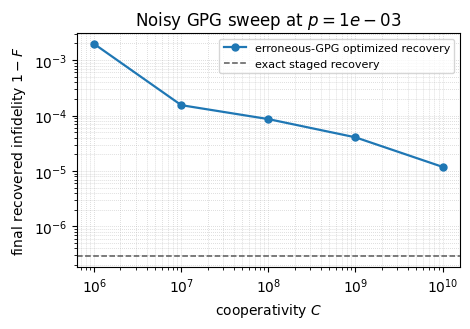

In [ ]:
fig, ax = plt.subplots(figsize=(4.8, 3.4))

ax.loglog(
    results["cooperativity"],
    results["GPG infidelity"],
    "o-",
    lw=1.6,
    ms=5,
    label="erroneous-GPG optimized recovery",
)
ax.axhline(
    results["exact infidelity"].iloc[0],
    color="0.35",
    ls="--",
    lw=1.1,
    label="exact staged recovery",
)

ax.set_xlabel(r"cooperativity $C$")
ax.set_ylabel(r"final recovered infidelity $1-F$")
ax.set_title(rf"Noisy GPG sweep at $p={P_AD:.0e}$")
ax.grid(True, which="both", ls=":", lw=0.55, alpha=0.65)
ax.legend(frameon=True, fontsize=8)
fig.tight_layout()

fig_dir = repo_root / "plots" / "AD"
fig_dir.mkdir(parents=True, exist_ok=True)
pdf_path = fig_dir / "noisy_gpg_cooperativity_sweep_p1e-3.pdf"
png_path = fig_dir / "noisy_gpg_cooperativity_sweep_p1e-3.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=240, bbox_inches="tight")

print(pdf_path)
print(png_path)
plt.show()

## Pulse diagnostics

This optional table reports which rank-one targets were hardest at each cooperativity.  It is useful for checking whether the noisy optimization is changing the pulse burden in the places we expect.

In [ ]:
diagnostic_rows = []

for C in COOPERATIVITIES:
    cache_key = gpgs.gpg_recovery_cache_key(P_AD, gpg_mode=GPG_MODE, cooperativity=C)
    point = noisy_cache["points"].get(cache_key)
    if point is None:
        continue
    for record in point["optimization_records"]:
        diagnostic_rows.append({"cooperativity": C, **record})

diagnostics = pd.DataFrame(diagnostic_rows)
if diagnostics.empty:
    print("No diagnostics available yet. Run the sweep cell first.")
else:
    hardest = (
        diagnostics.sort_values(["cooperativity", "1 - F_state"], ascending=[True, False])
        .groupby("cooperativity")
        .head(5)
        .reset_index(drop=True)
    )
    display(
        hardest[
            [
                "cooperativity",
                "factor",
                "eig_index",
                "pulses",
                "1 - F_state",
                "Tr_state",
                "elapsed_s",
                "source",
            ]
        ]
    )
